<a href="https://colab.research.google.com/github/kstrbova/ZSU_KS/blob/main/Exercise4_empty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fundamentals of Machine Learning - Exercise 4** 💪
---
---
### DBSCAN and Hierarchical Clustering
#### 🎯 Aim of the Exercise

- understand how **DBSCAN** identifies dense regions and noise,
- investigate the effect of `eps` and `min_samples`,
- apply **agglomerative hierarchical clustering** and interpret a dendrogram,
- compare clustering algorithms on two real-world datasets,
- interpret cluster profiles and justify whether a clustering solution is useful.


###  Why Another Clustering Algorithm?  
K-means requires us to specify `k`, searches for clusters around centroids, and assigns every observation to a cluster.    

Consider the following questions:  
- What if clusters have irregular shapes?  
- What if some observations do not belong to any dense group?  
- What if we want to inspect a hierarchy of possible groupings?  
Today we compare two alternatives:  

| Method | Main idea | Number of clusters | Noise |
|---|---|---|---|
| DBSCAN | Find connected dense regions | Not specified directly | Yes |
| Agglomerative clustering | Repeatedly merge the closest groups | Selected when cutting the hierarchy | No |

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

It identifies clusters as connected dense regions in which observations are
located sufficiently close to one another.

Unlike K-means, DBSCAN:

- does not require specifying the number of clusters in advance,
- can identify clusters with irregular shapes,
- may leave some observations unassigned and label them as **noise**.

### Main Idea

DBSCAN distinguishes three types of observations:

- **Core point** — has at least `min_samples` observations, including itself,
  within distance `eps`.
- **Border point** — does not satisfy the core-point condition itself, but lies
  within the `eps` neighbourhood of a core point.
- **Noise point** — is not reachable from any core point.

The algorithm connects neighbouring core points into clusters and assigns
reachable border points to those clusters. In scikit-learn, noise observations
receive the label `-1`.  

**Intuition:** A point is a **core point** if at least **min_samples** neighbors lie within distance **eps**. **Core points** and their density-reachable neighbors form a cluster; other points are **noise** (label **-1**).

![image-58.png](https://raw.githubusercontent.com/kstrbova/ZSU_KS/main/image-58.png)


### Key Parameters

- **`eps` (ε)** — the maximum distance between two observations for them to be
  considered neighbours. It defines the radius of the neighbourhood around
  each observation.

- **`min_samples`** — the minimum number of observations, including the point
  itself, required within the `eps` neighbourhood for the point to be
  considered a core point. basically our density level treshold

Changing these parameters changes the required density:

- smaller `eps` or larger `min_samples` → stricter density requirement,
  usually more noise,
- larger `eps` or smaller `min_samples` → less strict density requirement,
  clusters form and merge more easily.

### When Is DBSCAN Useful?

- clusters may have irregular shapes,
- isolated observations should not be forced into a cluster,
- the number of clusters is not known in advance,
- clusters have reasonably similar densities.

DBSCAN may struggle when:

- clusters have substantially different densities,
- features are not scaled appropriately,
- the data are high-dimensional,
- suitable values of `eps` and `min_samples` are difficult to identify.

📺 Let´s watch how DBSCAN works https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

 ### 🧩2. Guided Example: Old Faithful Geyser  
 The dataset describes eruptions of the Old Faithful geyser.
- `duration` — eruption duration,
- `waiting` — waiting time until the next eruption,
- `kind` — a known descriptive category.  
Each row represents one eruption.  

❓**Analytical question:** Can the numerical measurements reveal dense groups of eruptions, and how do DBSCAN and hierarchical clustering differ?

In [ ]:
geyser = sns.load_dataset("geyser")
geyser.head()

In [ ]:
print("Shape:", geyser.shape)
geyser.info()

🧩Let´s decide:

- which variables should define similarity between eruptions?
- which variable should be retained only for later interpretation?
- whether any preprocessing is required before calculating distances?

### Visualise and Prepare the Features

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=geyser,x="duration",y="waiting",color="grey")

plt.title("Old Faithful Eruptions")
plt.xlabel("Eruption duration")
plt.ylabel("Waiting time")
plt.show()

❓ How many dense regions do you expect to find?

❓ Are there any observations located between or outside the main dense regions?

### Scaling  
❓ Why do we scale the features before applying DBSCAN or hierarchical clustering?

In [ ]:
features = ["duration", "waiting"]

X = geyser[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print("Means:", X_scaled.mean(axis=0).round(2))
print("Standard deviations:", X_scaled.std(axis=0).round(2))

### Fit an Initial DBSCAN Model  
🧩 Create a DBSCAN model using `eps=0.30` and `min_samples=5`. Fit it to `X_scaled` and save the labels as `dbscan_labels`.

In [ ]:
# Create and fit the DBSCAN model


💡`fit_predict()` returns a cluster label for each eruption. The label `-1`indicates that an observation was classified as noise.

In [ ]:
geyser_results = geyser.copy()
geyser_results["dbscan_cluster"] = dbscan_labels

In [ ]:
#četnost
geyser_results["dbscan_cluster"].value_counts().sort_index()

🧩 Count the discovered clusters and noise observations. Remember that -1 is not a cluster.

In [ ]:
unique_labels = set(dbscan_labels)

# Calculate n_clusters and n_noise
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = (dbscan_labels == -1).sum()


print("Number of clusters:", n_clusters)
print("Number of noise observations:", n_noise)

💡 Jsou tam dva clustery, 0 a 1. Hodnota -1 představuje noise, proto ji od počtu clusterů odečítáme.

### Visualization

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=geyser_results,
    x="duration",
    y="waiting",
    hue="dbscan_cluster",
    palette="Set1")

plt.title("DBSCAN Clustering of Old Faithful Eruptions")
plt.show()

❓ Did we tell DBSCAN to create two clusters?  
❓ Are noise observations necessarily incorrect data?

#### How Does `eps` Affect the Result?  
The code below keeps `min_samples=5` and changes only eps.

In [ ]:
eps_values = [0.1, 0.2, 0.3, 0.5]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    ax.scatter(X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels,
        cmap="Set1",
        alpha=0.8)
    ax.set_title(f"eps={eps}\nclusters={n_clusters}, noise={n_noise}")
    ax.set_xlabel("Scaled duration")
    ax.set_ylabel("Scaled waiting")

plt.tight_layout()
plt.show()

#### Compare the Result with the Known Category  
The variable kind was not used to create the clusters. We now use it only to interpret the result.

In [ ]:
pd.crosstab(geyser_results["dbscan_cluster"],geyser_results["kind"],margins=True)

❓ Do the DBSCAN clusters correspond to the known `kind` categories?

❓ Does disagreement automatically mean that DBSCAN is wrong?

❓ Are noise observations necessarily data errors?

❓ Which value of `eps` gives the most defensible result, and why?

#### How Does `min_samples` Affect the Result?  

In [ ]:
min_samples_values = [3, 5, 10, 20]

for min_samples in min_samples_values:
    labels = DBSCAN(eps=0.3,min_samples=min_samples).fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(f"min_samples={min_samples}: "
        f"clusters={n_clusters}, noise={n_noise}")

❓ What happens when `min_samples` increases?

### How Can We Choose `eps`?  
So far, we have used `eps=0.30`. But how could we choose this value more systematically?

One useful diagnostic is a **k-distance plot**. For each observation, we calculate its distance to its `k`-th nearest neighbour, where `k = min_samples`.

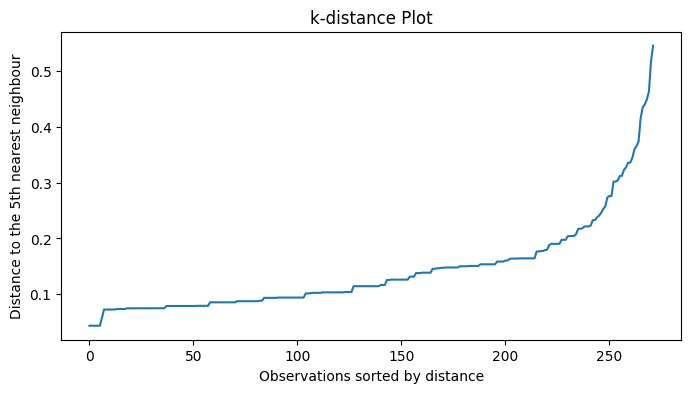

In [ ]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Observations sorted by distance")
plt.ylabel(f"Distance to the {min_samples}th nearest neighbour")
plt.title("k-distance Plot")
plt.show()

💡 The elbow provides a candidate value, not an objectively correct answer. We should still inspect the resulting clusters, noise observations, and parameter stability.

### Agglomerative Hierarchical Clustering  
- Agglomerative clustering begins with every observation as a separate cluster.   
- It repeatedly merges the closest groups until the required structure remains.  
- The linkage method defines how the distance between groups is measured. We use Ward linkage, which merges groups while trying to keep within-cluster variability small.  
- Unlike DBSCAN, the final partition assigns every observation to a cluster and does not create a noise category.

Inspect the Hierarchy with a Dendrogram
In a dendrogram:
- branches show which observations or groups were merged,
- the height of a merge represents the linkage distance,
- a horizontal cut produces a selected number of clusters.

In [ ]:
linkage_matrix = linkage( X_scaled,method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix,truncate_mode="level",p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations or merged groups")
plt.ylabel("Linkage distance")
plt.show()

❓ Where do you observe a relatively large increase in linkage distance?  
❓ How many clusters might be a reasonable choice?  
❓ Does the dendrogram prove that one number of clusters is objectively correct?  

### Create the Final Hierarchical Partition
🧩 Create an agglomerative model with two clusters and Ward linkage. Save its labels as `hierarchical_labels`.

In [ ]:
# Create and fit the hierarchical model

In [ ]:
geyser_results["hierarchical_cluster"] = hierarchical_labels
geyser_results["hierarchical_cluster"].value_counts().sort_index()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=geyser_results,
    x="duration",
    y="waiting",
    hue="dbscan_cluster",
    palette="Set1",
    ax=axes[0]
)
axes[0].set_title("DBSCAN")

sns.scatterplot(
    data=geyser_results,
    x="duration",
    y="waiting",
    hue="hierarchical_cluster",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Hierarchical Clustering")

plt.tight_layout()
plt.show()

❓ Do the algorithms identify similar main groups?  
❓ What happens to DBSCAN noise observations in hierarchical clustering?  
❓ Which result would you defend for these data, and why?

| Linkage method | Distance between clusters | Typical behaviour |
|---|---|---|
| `single` | Distance between the closest observations | Can capture irregular shapes but may create chains |
| `complete` | Distance between the most distant observations | Tends to produce compact clusters |
| `average` | Average distance between observations in both clusters | A compromise between single and complete linkage |
| `ward` | Increase in within-cluster variability after merging | Tends to produce compact, homogeneous clusters |

---

## 🧩 Independent Investigation: Wholesale Customers

The dataset contains annual spending by customers of a wholesale distributor
in six product categories. Each row represents one customer.

**Analytical question:** Can DBSCAN identify stable and interpretable groups of customers with similar
spending patterns and detect customers with unusual purchasing behaviour?

A valid conclusion may be that DBSCAN is not suitable for these data.

Can DBSCAN and hierarchical clustering identify useful customer segments with different spending patterns?
Your goal is not to force a particular number of clusters. You must evaluate whether each solution is stable and interpretable.

1 Load the Dataset  
The following package downloads the Wholesale Customers dataset from the UCI Machine Learning Repository

In [ ]:
!pip install ucimlrepo -q


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from ucimlrepo import fetch_ucirepo

wholesale = fetch_ucirepo(id=292)

customers = wholesale.data.features.copy()
region = wholesale.data.targets.copy()

customers.head()

In [ ]:
print("Shape:", customers.shape)
customers.info()

The six spending variables are strongly right-skewed. To save time, the preprocessing decision is provided:
1. log1p reduces the influence of extremely large spending values,
2. StandardScaler places the transformed features on comparable scales.
Channel is a categorical code and is not included in the distance-based feature matrix.

Feature selection

In [ ]:
spending_features = ["Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"]

X_customers = customers[spending_features].copy()
X_customers_log = np.log1p(X_customers)

customer_scaler = StandardScaler()
X_customers_prepared = customer_scaler.fit_transform(X_customers_log)

❓ Why do we exclude Channel from the feature matrix?  
❓ What problem does the log transformation address?  
❓ Why is scaling still needed after the log transformation?  

We will not use `Channel` or `Region` to construct the clusters. They describe
known customer characteristics and will be used only after clustering to help
interpret the result.

❓ Why would including `Channel` as the number 1 or 2 be problematic for
distance-based clustering?

Task A — DBSCAN Parameter Sensitivity  
Keep min_samples=5 and compare only three values of eps:

In [ ]:
eps_values = [0.7, 1.0, 1.3]

for eps in eps_values:
    # Fit DBSCAN
    # Count clusters and noise
    # Print one summary line
    pass

For each value, report:
- number of clusters,
- number of noise observations,
- percentage of noise.

❓ How sensitive is DBSCAN to the selected eps?  
❓ Which result is most defensible? Consider both the number of clusters and the amount of noise.  
❓ Would a solution with a high percentage of noise be useful for customer segmentation?

Select one of the tested values and fit the DBSCAN model again. Store the labels as customer_dbscan_labels.

In [ ]:
selected_eps = ...

# Fit the selected DBSCAN model and create customer_dbscan_labels

Task B — Hierarchical Clustering  
Use Ward linkage and compare k = 2, 3, 4. Calculate the silhouette score for each solution.

In [ ]:
for k in [2, 3, 4]:
    # Fit the model
    # Calculate the silhouette score
    # Print k and the score
    pass

Select one value of k. Your decision should consider the silhouette score and whether the number of segments would be useful and interpretable.

In [ ]:
selected_k = ...

# Fit the selected hierarchical model and create customer_hierarchical_labels

Compare and Interpret the Solutions

In [ ]:
customer_results = customers.copy()
customer_results["dbscan_cluster"] = customer_dbscan_labels
customer_results["hierarchical_cluster"] = customer_hierarchical_labels

print("DBSCAN cluster sizes:")
print(customer_results["dbscan_cluster"].value_counts().sort_index())

print("\nHierarchical cluster sizes:")
print(customer_results["hierarchical_cluster"].value_counts().sort_index())

Create cluster profiles in the standardised feature space. Include the DBSCAN noise group (-1) so that you can examine what makes it unusual.

In [ ]:
scaled_customers = pd.DataFrame(X_customers_prepared,
    columns=spending_features,
    index=customers.index)

scaled_customers["dbscan_cluster"] = customer_dbscan_labels
scaled_customers["hierarchical_cluster"] = customer_hierarchical_labels

dbscan_profiles = (scaled_customers
    .groupby("dbscan_cluster")[spending_features]
    .mean())

hierarchical_profiles = (
    scaled_customers
    .groupby("hierarchical_cluster")[spending_features]
    .mean())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(dbscan_profiles,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".1f",
    ax=axes[0])
axes[0].set_title("DBSCAN Profiles")

sns.heatmap(hierarchical_profiles,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".1f",
    ax=axes[1])
axes[1].set_title("Hierarchical Profiles")

plt.tight_layout()
plt.show()

Final Decision

1. How many clusters did each algorithm produce?
2. How much noise did DBSCAN identify?
3. How sensitive was DBSCAN to eps?
4. Which spending categories distinguish the main customer groups?
5. Which algorithm would you select for further interpretation?
6. What is one limitation of your conclusion?

Exit Ticket
1. How does DBSCAN determine clusters without specifying k?
2. What is the difference between a cluster and noise in DBSCAN?
3. What information does a dendrogram provide?
4. Why does hierarchical clustering assign DBSCAN noise observations to clusters?
5. Why might two clustering algorithms produce different but defensible results?

## Comparing the three methods

| Method | You choose… | Strengths | Watch outs |
|--------|----------------|-----------|------------|
| **K-Means** | **k** (e.g. via **elbow**) | Fast, simple, good for round, similar-sized groups | Poor if clusters are elongated, unequal size, or non-convex |
| **Hierarchical** | **n_clusters** (or cut height) | **Dendrogram** shows nested structure; flexible with **linkage** | Costly for very large **n**; single linkage can **chain** |
| **DBSCAN** | **eps**, **min_samples** | Arbitrary shapes; explicit **noise** (outliers); no fixed **k** | Sensitive to **scaling** and **density**; varying density is hard |

> **Note:**  Always validate clusters with domain knowledge, visual inspection and multiple views of the data.